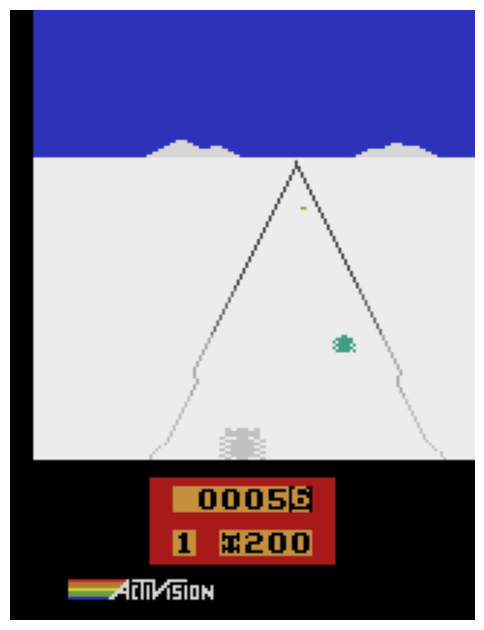

Entorno cerrado correctamente.


In [2]:
import gymnasium as gym
import ale_py
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

# 1. Crear el entorno con rgb_array en lugar de human
env = gym.make("ALE/Enduro-v5", render_mode="rgb_array")

# Preparar la figura para mostrar la imagen
fig, ax = plt.subplots(figsize=(6, 8))
# Obtener el primer frame para inicializar la imagen
observation, info = env.reset()
img = ax.imshow(env.render())
plt.axis('off')

try:
    max_steps = 1000
    for step in range(max_steps):
        action = env.action_space.sample()
        observation, reward, terminated, truncated, info = env.step(action)
        
        # 2. Actualizar la imagen mostrada en la celda
        img.set_data(env.render())
        clear_output(wait=True)
        display(fig)
        
        if terminated or truncated:
            print(f"Juego terminado en el paso {step}")
            break
            
except KeyboardInterrupt:
    print("Ejecución interrumpida manualmente.")
except Exception as e:
    print(f"Ocurrió un error: {e}")
finally:
    env.close()
    plt.close(fig) # Cerrar la figura de matplotlib
    print("Entorno cerrado correctamente.")


In [ ]:
import gymnasium as gym
import ale_py
import pygame # Necesitamos importar pygame explícitamente

# 1. Crear el entorno
env = gym.make("ALE/Enduro-v5", render_mode="human")
try:
    # 2. Reiniciar el entorno
    observation, info = env.reset()
    
    # Ajuste de número de pasos (cada 100 pasos son aprox. 7 segundos)
    max_steps = 500
    
    for step in range(max_steps):
        # 3. Acción aleatoria
        action = env.action_space.sample()
        
        # 4. Aplicar acción
        observation, reward, terminated, truncated, info = env.step(action)
        env.render()
        
        # 5. Salir si termina
        if terminated or truncated:
            print(f"Juego terminado prematuramente en el paso {step}")
            break
            
    else:
        # Esto se ejecuta solo si el 'for' termina todos los pasos sin hacer un 'break'
        print(f"Se alcanzó el límite de {max_steps} pasos fijado en el bucle. (El juego aún no termina en realidad).")
except KeyboardInterrupt:
    print("Ejecución interrumpida manualmente.")
except Exception as e:
    print(f"Ocurrió un error: {e}")
finally:
    # 6. Forzar el cierre de pygame ANTES de cerrar el entorno
    try:
        pygame.display.quit()
        pygame.quit()
    except Exception:
        pass
        
    env.close()
    print("Entorno cerrado correctamente sin crashear.")

Se alcanzó el límite de 500 pasos fijado en el bucle. (El juego aún no termina en realidad).
Entorno cerrado correctamente sin crashear.
